<a href="https://colab.research.google.com/github/Abhisek7602/Financial-Analytics---Portfolio-Risk-Volatility-Monitor-/blob/main/financa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WEEK-1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tcs = pd.read_csv("tcs.csv")
rel = pd.read_csv("Reliance.csv")
hdfc = pd.read_csv("HDFCBANK.NS.csv")
sbi = pd.read_csv("SBI Dataset.csv")

In [4]:
tcs.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2013-04-29,682.50,692.349976,682.500000,685.375000,555.524414,3968916,0.0,0.0
1,2013-04-30,684.00,691.000000,682.500000,689.200012,558.624695,4020570,0.0,0.0
2,2013-05-02,686.75,719.400024,686.750000,716.950012,581.117065,5630326,0.0,0.0
3,2013-05-03,713.00,723.625000,703.950012,709.250000,574.875916,3641790,0.0,0.0
4,2013-05-06,710.00,736.200012,710.000000,733.599976,594.612488,3727118,0.0,0.0


In [5]:
rel.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0


In [6]:
hdfc.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,01-01-1996,3.030,3.030,2.925,2.980,2.417746,350000.0
1,02-01-1996,2.980,3.025,2.950,2.975,2.413689,412000.0
2,03-01-1996,2.975,2.995,2.950,2.985,2.421803,284000.0
3,04-01-1996,2.985,2.980,2.940,2.965,2.405575,282000.0
4,05-01-1996,2.965,2.980,2.950,2.960,2.401519,189000.0


In [7]:
sbi.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2000,22.267092,22.988886,22.101974,22.988886,15.844801,25152894.0
1,04-01-2000,22.988886,24.720245,22.535995,24.446625,16.849524,47648560.0
2,05-01-2000,23.493668,24.974997,23.116261,23.441774,16.156942,36396207.0
3,06-01-2000,23.776726,25.286358,23.776726,24.625893,16.973083,70573968.0
4,07-01-2000,24.673071,26.409147,24.059780,25.786425,17.772966,83453217.0


In [8]:
for df in [tcs, rel, hdfc, sbi]:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
    df.sort_values('Date', inplace=True)


/tmp/ipykernel_2735/3298541933.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
/tmp/ipykernel_2735/3298541933.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


In [9]:
for name, df in zip(['TCS','Reliance','HDFC','SBI'], [tcs, rel, hdfc, sbi]):
    print(name)
    print(df.isna().sum())


TCS
Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Reliance
Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64
HDFC
Date         0
Open         7
High         7
Low          7
Close        7
Adj Close    7
Volume       7
dtype: int64
SBI
Date         0
Open         9
High         9
Low          9
Close        9
Adj Close    9
Volume       9
dtype: int64


In [10]:
def keep_price(df):
    if 'Adj Close' in df.columns:
        return df[['Date', 'Adj Close']].rename(columns={'Adj Close':'Price'})
    else:
        return df[['Date', 'Close']].rename(columns={'Close':'Price'})

tcs = keep_price(tcs)
rel = keep_price(rel)
hdfc = keep_price(hdfc)
sbi = keep_price(sbi)


In [11]:
for name, df in zip(['TCS','Reliance','HDFC','SBI'], [tcs, rel, hdfc, sbi]):
    print(name)
    print(df.isna().sum())


TCS
Date     0
Price    0
dtype: int64
Reliance
Date     0
Price    1
dtype: int64
HDFC
Date     0
Price    7
dtype: int64
SBI
Date     0
Price    9
dtype: int64


In [12]:
tcs.dropna(inplace=True)
rel.dropna(inplace=True)
hdfc.dropna(inplace=True)
sbi.dropna(inplace=True)

In [13]:
portfolio = tcs.merge(rel, on='Date', how='inner', suffixes=('_TCS','_REL'))
portfolio = portfolio.merge(hdfc, on='Date', how='inner')
portfolio = portfolio.merge(sbi, on='Date', how='inner')

portfolio.columns = ['Date','TCS','Reliance','HDFC','SBI']

portfolio.head()

,Date,TCS,Reliance,HDFC,SBI
0,2015-11-18,1013.830811,436.671021,506.823273,221.892380
1,2015-11-19,1018.616150,447.563873,516.634888,224.562454
2,2015-11-20,1034.051636,453.357422,517.577454,223.687759
3,2015-11-23,1030.904419,456.661224,515.257507,223.457596
4,2015-11-24,1020.944702,463.340515,514.435852,222.260651


In [14]:
portfolio.info()
portfolio.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232 entries, 0 to 1231
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1232 non-null   datetime64[ns]
 1   TCS       1232 non-null   float64       
 2   Reliance  1232 non-null   float64       
 3   HDFC      1232 non-null   float64       
 4   SBI       1232 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 48.3 KB


,Date,TCS,Reliance,HDFC,SBI
count,1232,1232.000000,1232.000000,1232.000000,1232.000000
mean,2018-05-18 18:58:26.493506304,1529.280337,1024.471417,902.075661,245.445747
min,2015-11-18 00:00:00,922.371155,434.061554,455.614166,139.764572
25%,2017-02-15 18:00:00,1090.439819,540.720703,646.391709,211.436943
50%,2018-05-16 12:00:00,1564.062317,946.843903,940.300293,251.947593
75%,2019-08-19 06:00:00,1921.099365,1298.972321,1077.250122,278.561257
max,2020-11-17 00:00:00,2695.005615,2324.550049,1402.380493,350.519379
std,NaN,449.785411,466.231636,237.287392,47.178347


WEEK-2

In [15]:
import numpy as np

prices = portfolio[['TCS','Reliance','HDFC','SBI']]

log_returns = np.log(prices / prices.shift(1))

log_returns.head()

,TCS,Reliance,HDFC,SBI
0,NaN,NaN,NaN,NaN
1,0.004709,0.024639,0.019174,0.011961
2,0.015040,0.012862,0.001823,-0.003903
3,-0.003048,0.007261,-0.004492,-0.001029
4,-0.009708,0.014520,-0.001596,-0.005371


In [16]:
volatility = log_returns.std()

volatility

,0
TCS,0.016284
Reliance,0.019370
HDFC,0.014809
SBI,0.023712


In [17]:
rolling_vol = log_returns.rolling(window=30).std()

rolling_vol

,TCS,Reliance,HDFC,SBI
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
1227,0.019230,0.023922,0.018942,0.023221
1228,0.018895,0.024865,0.019066,0.022951
1229,0.018965,0.024880,0.019450,0.024068
1230,0.018920,0.024981,0.019398,0.023810


In [18]:
VaR_95 = log_returns.quantile(0.05)

VaR_95

,0.05
TCS,-0.024609
Reliance,-0.025796
HDFC,-0.017939
SBI,-0.035954


In [19]:
weights = np.array([0.25,0.25,0.25,0.25])

In [20]:
mean_returns = log_returns.mean()
cov_matrix = log_returns.cov()

In [21]:
num_simulations = 5000
num_days = 252   # 1 trading year

results = np.zeros((num_days, num_simulations))

for i in range(num_simulations):
    simulated_returns = np.random.multivariate_normal(
        mean_returns, cov_matrix, num_days
    )
    portfolio_path = np.cumprod(1 + simulated_returns.dot(weights))
    results[:, i] = portfolio_path

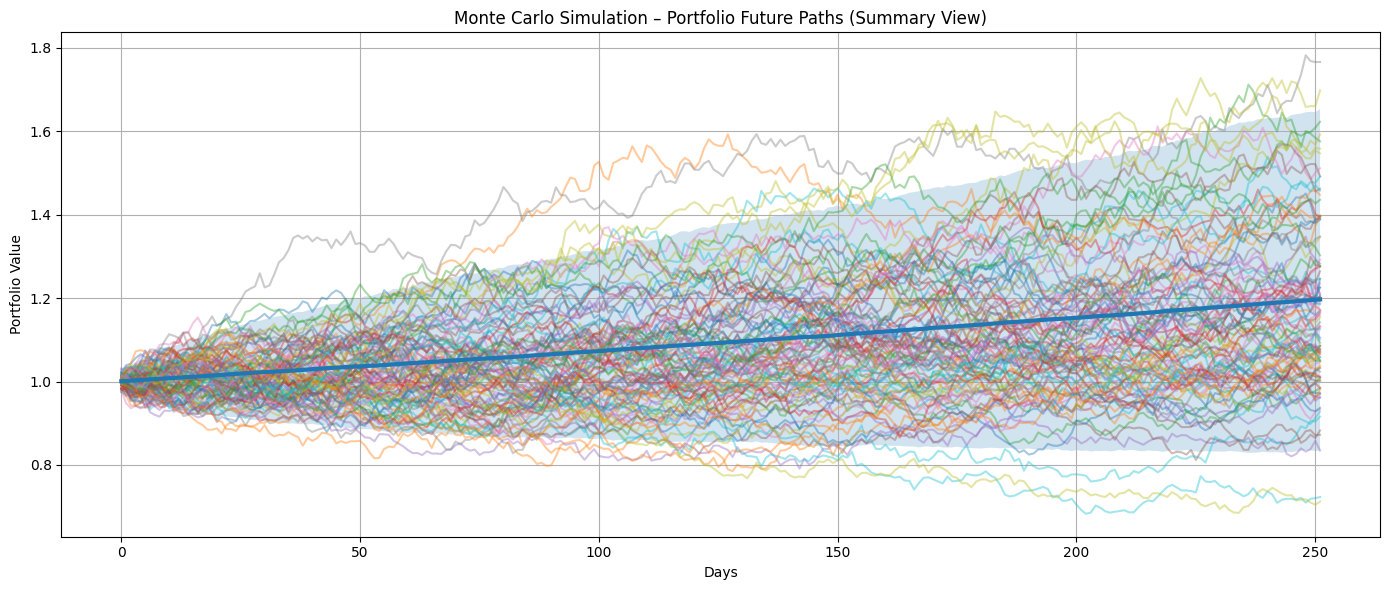

In [22]:
plt.figure(figsize=(14,6))

# Plot only first 100 paths for clarity
plt.plot(results[:, :100], alpha=0.4)

# Mean path
mean_path = results.mean(axis=1)
plt.plot(mean_path, linewidth=3)

# Percentile bands
p5 = np.percentile(results, 5, axis=1)
p95 = np.percentile(results, 95, axis=1)

plt.fill_between(range(num_days), p5, p95, alpha=0.2)

plt.title("Monte Carlo Simulation – Portfolio Future Paths (Summary View)")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
portfolio.to_csv("portfolio_prices.csv", index=False)
log_returns.to_csv("portfolio_log_returns.csv", index=False)
rolling_vol.to_csv("portfolio_rolling_volatility.csv", index=False)
VaR_95.to_csv("portfolio_VaR95.csv")

In [24]:
rolling_vol_export = rolling_vol.copy()
rolling_vol_export["Date"] = portfolio["Date"]

rolling_vol_export.to_csv("portfolio_rolling_volatility.csv", index=False)

In [25]:
log_returns_export = log_returns.copy()
log_returns_export["Date"] = portfolio["Date"]

log_returns_export.to_csv("portfolio_log_returns.csv", index=False)

In [26]:
VaR_95_export = VaR_95.reset_index()
VaR_95_export.columns = ["Stock", "VaR_95"]

VaR_95_export.to_csv("portfolio_VaR95.csv", index=False)

WEEK-4

In [27]:
prices = pd.read_csv("portfolio_prices.csv")


prices["Date"] = pd.to_datetime(prices["Date"])
prices.set_index("Date", inplace=True)

stocks = ["TCS", "Reliance", "HDFC", "SBI"]

prices = prices[stocks]

prices.head()

,TCS,Reliance,HDFC,SBI
Date,,,,
2015-11-18,1013.830811,436.671021,506.823273,221.892380
2015-11-19,1018.616150,447.563873,516.634888,224.562454
2015-11-20,1034.051636,453.357422,517.577454,223.687759
2015-11-23,1030.904419,456.661224,515.257507,223.457596
2015-11-24,1020.944702,463.340515,514.435852,222.260651


In [28]:
prices = pd.read_csv("portfolio_prices.csv")


prices["Date"] = pd.to_datetime(prices["Date"])
prices.set_index("Date", inplace=True)

stocks = ["TCS", "Reliance", "HDFC", "SBI"]

prices = prices[stocks]

prices.head()

,TCS,Reliance,HDFC,SBI
Date,,,,
2015-11-18,1013.830811,436.671021,506.823273,221.892380
2015-11-19,1018.616150,447.563873,516.634888,224.562454
2015-11-20,1034.051636,453.357422,517.577454,223.687759
2015-11-23,1030.904419,456.661224,515.257507,223.457596
2015-11-24,1020.944702,463.340515,514.435852,222.260651


In [29]:
returns = prices.pct_change().dropna()
returns.head()

,TCS,Reliance,HDFC,SBI
Date,,,,
2015-11-19,0.004720,0.024945,0.019359,0.012033
2015-11-20,0.015153,0.012945,0.001824,-0.003895
2015-11-23,-0.003044,0.007287,-0.004482,-0.001029
2015-11-24,-0.009661,0.014626,-0.001595,-0.005356
2015-11-26,-0.009460,0.021649,-0.000376,0.004557


In [30]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

mean_returns, cov_matrix

(TCS         0.000882
 Reliance    0.001422
 HDFC        0.000937
 SBI         0.000298
 dtype: float64,
                TCS  Reliance      HDFC       SBI
 TCS       0.000265  0.000079  0.000061  0.000063
 Reliance  0.000079  0.000378  0.000116  0.000153
 HDFC      0.000061  0.000116  0.000218  0.000147
 SBI       0.000063  0.000153  0.000147  0.000576)

In [31]:
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

    portfolio_return = np.sum(mean_returns * weights) * 252
    portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix * 252, weights)))

    sharpe = portfolio_return / portfolio_vol

    results[0, i] = portfolio_return
    results[1, i] = portfolio_vol
    results[2, i] = sharpe

    weights_record.append(weights)

results_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe"])
weights_df = pd.DataFrame(weights_record, columns=stocks)

portfolios = pd.concat([results_df, weights_df], axis=1)

portfolios.head()


,Return,Volatility,Sharpe,TCS,Reliance,HDFC,SBI
0,0.204177,0.239136,0.853809,0.082312,0.284713,0.225670,0.407305
1,0.183094,0.226019,0.810084,0.110049,0.049096,0.484080,0.356775
2,0.199180,0.216878,0.918394,0.201948,0.173023,0.281827,0.343203
3,0.176942,0.289675,0.610828,0.031233,0.331585,0.020596,0.616586
4,0.193830,0.230213,0.841958,0.203722,0.218219,0.167384,0.410674


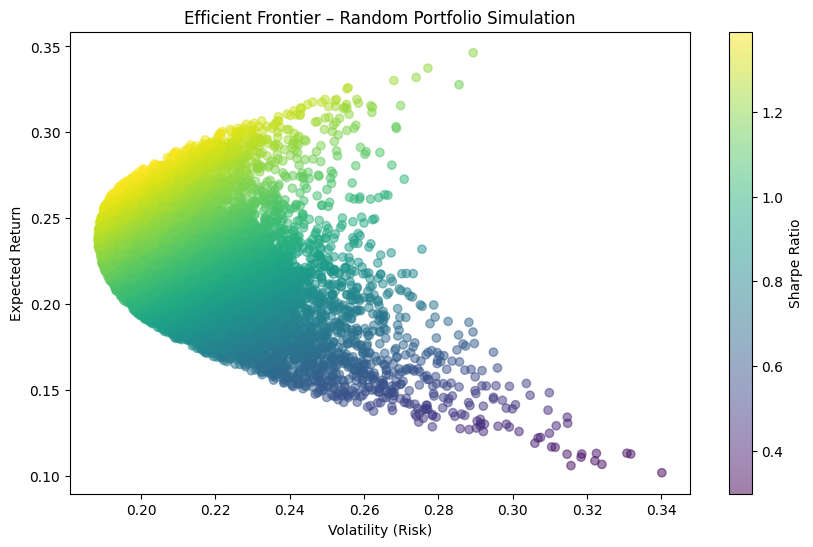

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(
    portfolios["Volatility"],
    portfolios["Return"],
    c=portfolios["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier – Random Portfolio Simulation")

plt.show()

In [33]:
max_sharpe = portfolios.loc[portfolios["Sharpe"].idxmax()]


min_vol = portfolios.loc[portfolios["Volatility"].idxmin()]

max_sharpe, min_vol

(Return        0.278446
 Volatility    0.200510
 Sharpe        1.388687
 TCS           0.300348
 Reliance      0.384451
 HDFC          0.312253
 SBI           0.002947
 Name: 7874, dtype: float64,
 Return        0.237245
 Volatility    0.188458
 Sharpe        1.258876
 TCS           0.379972
 Reliance      0.121445
 HDFC          0.446389
 SBI           0.052194
 Name: 2684, dtype: float64)

In [34]:
summary = pd.DataFrame({
    "Metric": ["Return", "Volatility", "Sharpe"],
    "Max Sharpe": [
        max_sharpe["Return"],
        max_sharpe["Volatility"],
        max_sharpe["Sharpe"]
    ],
    "Min Volatility": [
        min_vol["Return"],
        min_vol["Volatility"],
        min_vol["Sharpe"]
    ]
})

summary

,Metric,Max Sharpe,Min Volatility
0,Return,0.278446,0.237245
1,Volatility,0.200510,0.188458
2,Sharpe,1.388687,1.258876


In [35]:
summary.to_csv("week4_portfolio_summary.csv", index=False)
portfolios.to_csv("week4_all_portfolios.csv", index=False)

## Week-4 focused on portfolio optimization through Monte Carlo–style random weight simulation. The Efficient Frontier was generated to visualize the risk-return trade-off. The portfolio with the maximum Sharpe ratio and the minimum volatility portfolio were identified and summarized for investment decision-making.